# Práctica - Clase 4: Aprendizaje Automático

## Actividad 1: Regresión Lineal para Esperanza de Vida

En este cuaderno vamos a resolver paso a paso la Actividad 1. El objetico es entrenar un modelo que sea capaz de predecir la Esperanza de Vida de un pais, basandose en diferentes factores de salud, economia y educacion.

### 1. Importación de librerías
Se usa `pandas` y `numpy` para manejar los datos, `matplotlib` y `seaborn` para hacer gráficos y `scikit-learn` para toda la matemática del modelo.

In [182]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn import metrics

sns.set_theme(style="whitegrid")

### 2. Carga de Datos y Limpieza Inicial
Carga de los datos crudos. Antes de imputar los valores faltantes, se realiza una inspeccion de cuantos nulos hay por columna y se visualizan los outliners, ya que esto nos va a ayudar a decidir la estrategia de limpieza.

**Nota sobre `Year`:** La columna Year se conserva como predictor numerico porque captura la tendencia temporal de mejora en la esperanza de vida a lo largo de los anios (2000-2015). No es una variable categorica en este contexto.

In [183]:
# Cargar datos y limpiar nombres de columnas
df_raw = pd.read_csv("../datos/Life Expectancy Data.csv")
df_raw.columns = df_raw.columns.str.strip()

# Eliminar filas donde no sepamos la esperanza de vida (nuestra variable objetivo)
df_raw = df_raw.dropna(subset=["Life expectancy"])

# Inspeccion de valores nulos
nulos = df_raw.isnull().sum()
nulos_pct = (nulos / len(df_raw) * 100).round(1)
nulos_info = pd.DataFrame({"Nulos": nulos, "Porcentaje (%)": nulos_pct})
print("Valores nulos por columna:")
display(nulos_info[nulos_info["Nulos"] > 0].sort_values("Porcentaje (%)", ascending=False))

Valores nulos por columna:


,Nulos,Porcentaje (%)
Population,644,22.0
Hepatitis B,553,18.9
GDP,443,15.1
Total expenditure,226,7.7
Alcohol,193,6.6
Schooling,160,5.5
Income composition of resources,160,5.5
BMI,32,1.1
thinness 1-19 years,32,1.1
thinness 5-9 years,32,1.1


### 3. Exploracion de los datos (AED)
Segun la teoria de la clase 4, el AED debe organizar y desplegar los datos graficamente para percibir valores extremos, atipicos y patrones globales **antes** de transformarlos.

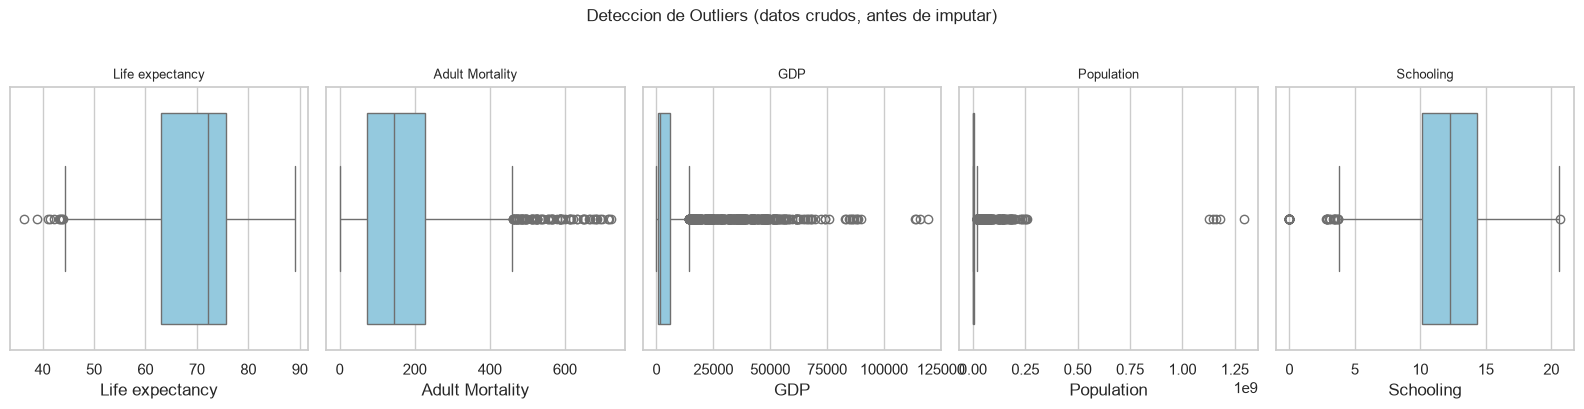

In [184]:
# Deteccion visual de outliners sobre los datos crudos
cols_boxplot = ["Life expectancy", "Adult Mortality", "GDP", "Population", "Schooling"]
fig, axes = plt.subplots(1, len(cols_boxplot), figsize=(16, 4))
for i, col in enumerate(cols_boxplot):
    sns.boxplot(x=df_raw[col].dropna(), ax=axes[i], color="skyblue")
    axes[i].set_title(col, fontsize=9)
plt.suptitle("Deteccion de Outliers (datos crudos, antes de imputar)", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

Los bloxplots revelan la presencia de valores atipicos claros en varias columnas.`GDP` y `Population` presentan colas largas hacia la derecha (paises con economias o poblaciones enormes frente a la mayoria). `Adult Mortality` muestra outliers altos correspondientes a paises en crisis sanitaria. Estos valores extremos confirman la decision de imputar datos faltantes con la **mediana** en lugar del promedio, ya que la mediana no se ve afectada por estos extremos.

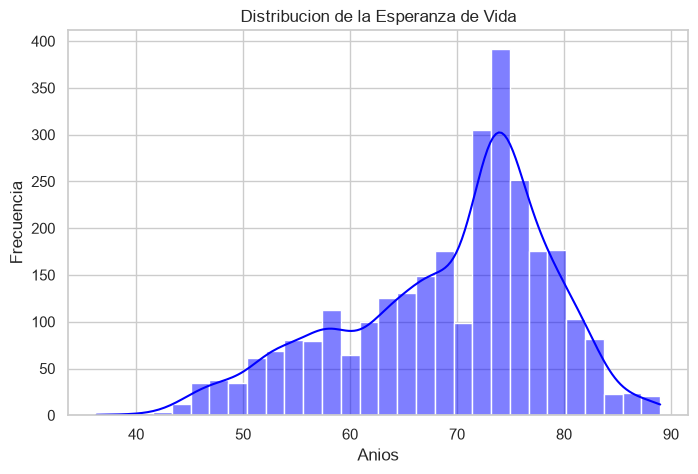

In [185]:
# Histograma de la variable objetivo
plt.figure(figsize=(8, 5))
sns.histplot(df_raw["Life expectancy"], kde=True, color="blue", bins=30)
plt.title("Distribucion de la Esperanza de Vida")
plt.xlabel("Anios")
plt.ylabel("Frecuencia")
plt.show()

La distribucion de la esperanza de vida presenta un ligero sesgo negativo, concentrandose la mayoria de los paises entre 65 y 80 anios. Un grupo mas pequenio se situa por debajo de 55 anios, correspondiente a paises en vias de desarrollo con altos indices de mortalidad. La forma general se acerca a una distribucion normal, lo cual nos es favorable para aplicar regresion lineal.

### 4. Preparacion de los Datos

La imputacion con mediana y el escalado se van a realizar despues de dividir los datos, usando un pipeline de scikitlearn. Esto evita la fuga de datos, ya que si imputamos y escalamos antes de dividir, el conjunto de prueba conoceria estadisticas de su posterior entrenamiento, contaminando la evaluacionm.

In [186]:
# Convertir variables categoricas
df = pd.get_dummies(df_raw, columns=["Status"], drop_first=True)

# Guardamos la columna Country para la division por grupos, pero la sacamos de predictores
paises = df["Country"]
df = df.drop(columns=["Country"])

#### 4.1 Eliminacion de columnas redundantes
Antes de descartar columnas por correlacion lineal multiple, mostramos las correlaciones que lo justifican.

In [187]:
# Evidencia numerica de multicolinealidad
pares_redundantes = [
    ("infant deaths", "under-five deaths"),
    ("thinness  1-19 years", "thinness 5-9 years"),
    ("GDP", "percentage expenditure"),
]

print("Correlaciones entre pares redundantes:")
for a, b in pares_redundantes:
    if a in df.columns and b in df.columns:
        corr_val = df[a].corr(df[b])
        print(f"  {a} vs {b}: {corr_val:.3f}")

Correlaciones entre pares redundantes:
  infant deaths vs under-five deaths: 0.997
  thinness  1-19 years vs thinness 5-9 years: 0.939
  GDP vs percentage expenditure: 0.899


In [188]:
# Se eliminan solo los pares con correlacion > 0.95 para evitar que sea extramadamente redundante 
# Ej: GDP vs percentage expenditure (0.90) se conservan ambas porque no superan 0.95
df = df.drop(columns=["under-five deaths", "thinness 5-9 years"], errors="ignore")

print(f"Columnas finales ({len(df.columns)}): {list(df.columns)}")

Columnas finales (19): ['Year', 'Life expectancy', 'Adult Mortality', 'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B', 'Measles', 'BMI', 'Polio', 'Total expenditure', 'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness  1-19 years', 'Income composition of resources', 'Schooling', 'Status_Developing']


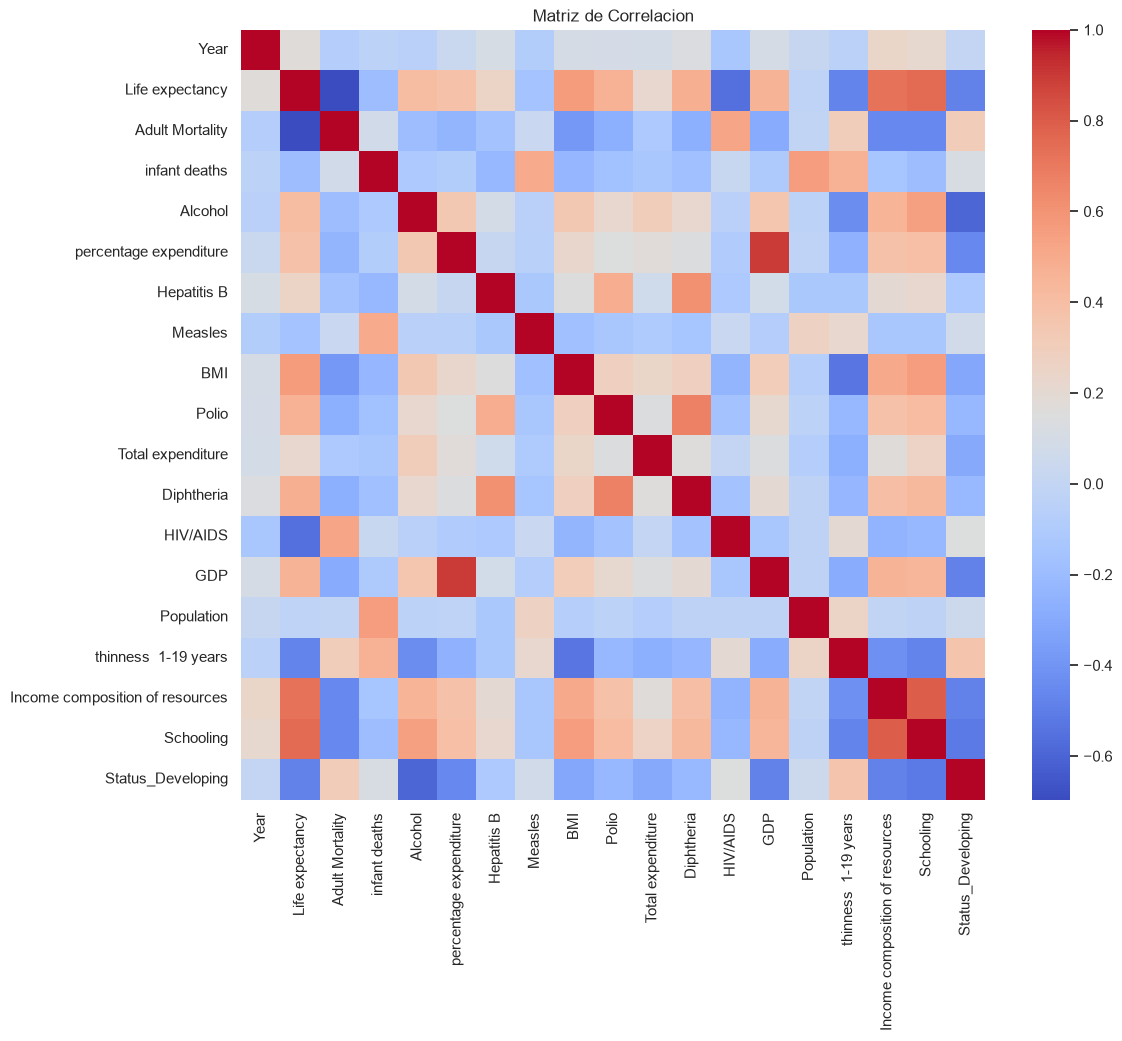

In [189]:
# Heatmap de correlacion (sobre los datos ya limpios, sin las columnas redundantes)
plt.figure(figsize=(12, 10))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm")
plt.title("Matriz de Correlacion")
plt.show()

El mapa de calor muestra fuertes correlaciones positivas entre la esperanza de vida y variables como `Schooling` e `Income composition of resources` (tonos naranjas/rojos). Al contrario de `Adult Mortality` y `HIV/AIDS` que muestran correlaciones negativas marcadas (tonos azules).

In [190]:
# Respaldo numerico: correlaciones de cada variable con Life expectancy
corr_target = corr_matrix["Life expectancy"].drop("Life expectancy").sort_values(ascending=False)
corr_display = pd.DataFrame({
    "Variable": corr_target.index,
    "Correlacion": corr_target.values
})
print("Correlacion de cada variable con Life expectancy (ordenada de mayor a menor):")
display(corr_display)

Correlacion de cada variable con Life expectancy (ordenada de mayor a menor):


,Variable,Correlacion
0,Schooling,0.751975
1,Income composition of resources,0.724776
2,BMI,0.567694
3,Diphtheria,0.479495
4,Polio,0.465556
5,GDP,0.461455
6,Alcohol,0.404877
7,percentage expenditure,0.381864
8,Hepatitis B,0.256762
9,Total expenditure,0.218086


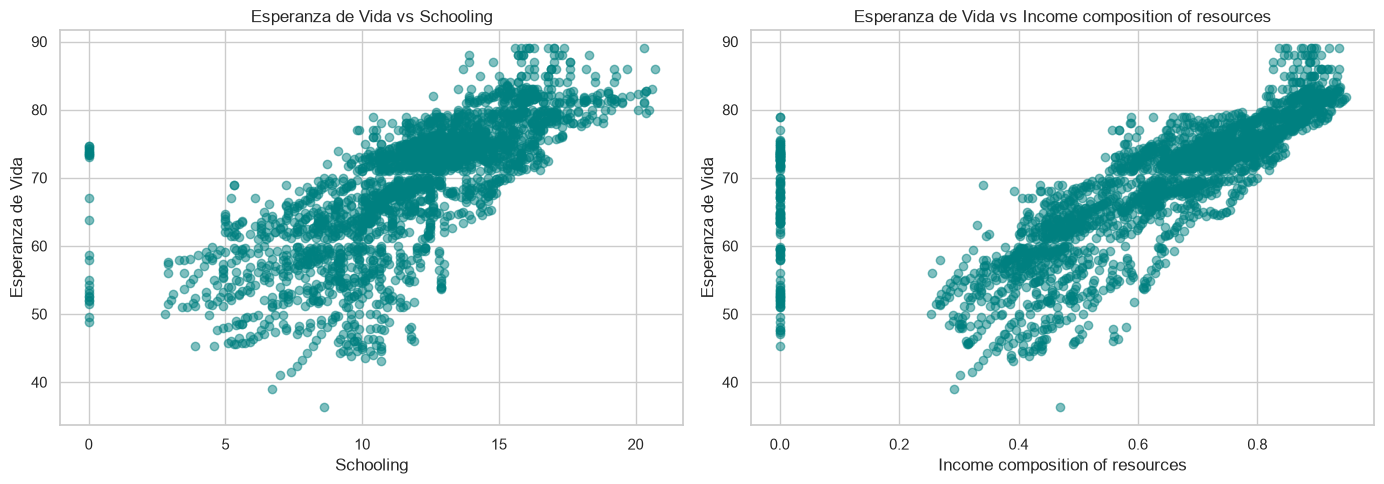

In [191]:
# Graficos de dispersion: top 2 variables mas correlacionadas con la variable objetivo
top_vars = corr_matrix["Life expectancy"].abs().sort_values(ascending=False).index[1:3]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, var in enumerate(top_vars):
    axes[i].scatter(df[var], df["Life expectancy"], alpha=0.5, color="teal")
    axes[i].set_title(f"Esperanza de Vida vs {var}")
    axes[i].set_xlabel(var)
    axes[i].set_ylabel("Esperanza de Vida")
plt.tight_layout()
plt.show()

Los graficos de dispersion confirman la relacion practicamente lineal entre las variables mas correlacionadas y la esperanza de vida. Se observa una nube de puntos con tendencia ascendente clara, aunque con mayor dispersion en los extremos bajos (paises con bajo desarrollo o poca escolaridad). Esto sugiere que un modelo lineal es razonable, pero podria subestimar o sobreestimar en los extremos.

### 5. Division de Datos y Modelado

Cada pais aparece hasta 16 veces en el dataset (2000-2015). Si dividimos de forma puramente aleatoria, el mismo pais queda en entrenamiento y en prueba, lo cual infla artificialmente las metricas. Usamos `GroupShuffleSplit` para que todos los registros de un mismo pais caigan en el mismo grupo (train o test).

El `Pipeline` encadena: `SimpleImputer` (mediana) → `StandardScaler` → `LinearRegression`, asegurando que la imputacion y el escalado se ajusten unicamente con los datos de entrenamiento.

In [192]:
# Definicion de X e Y
X = df.drop(columns=["Life expectancy"])
y = df["Life expectancy"]

# Division por pais (groupShuffleSplit) - 80% / 20%
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=paises))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print(f"Entrenamiento: {len(X_train)} filas | Prueba: {len(X_test)} filas")
print(f"Paises en train: {paises.iloc[train_idx].nunique()} | Paises en test: {paises.iloc[test_idx].nunique()}")

Entrenamiento: 2336 filas | Prueba: 592 filas
Paises en train: 146 | Paises en test: 37


In [193]:
# Pipeline: Imputacion + Escalado + Regresion Lineal
pipeline_lr = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LinearRegression()),
])

pipeline_lr.fit(X_train, y_train)
print("El modelo de Regresion Lineal ha sido entrenado exitosamente.")

El modelo de Regresion Lineal ha sido entrenado exitosamente.


### 6. Evaluacion del Modelo y sus metricas
Calculamos las cinco metricas presentadas en la teoria. Mostramos las metricas tanto en entrenamiento como en prueba para verificar que no haya un sobreajuste.

In [194]:
# Prediccion sobre entrenamiento y prueba
y_pred_train = pipeline_lr.predict(X_train)
y_pred_test = pipeline_lr.predict(X_test)

def mostrar_metricas(y_real, y_pred, nombre_set):
    mae = metrics.mean_absolute_error(y_real, y_pred)
    mse = metrics.mean_squared_error(y_real, y_pred)
    medae = metrics.median_absolute_error(y_real, y_pred)
    r2 = metrics.r2_score(y_real, y_pred)
    evs = metrics.explained_variance_score(y_real, y_pred)
    print(f"--- {nombre_set} ---")
    print(f"  Error Absoluto Medio (MAE):      {mae:.2f}")
    print(f"  Error Cuadratico Medio (MSE):     {mse:.2f}")
    print(f"  Error Absoluto Mediano (MedAE):   {medae:.2f}")
    print(f"  Puntuacion R2:                    {r2:.4f}")
    print(f"  Varianza Explicada:               {evs:.4f}")
    print()

mostrar_metricas(y_train, y_pred_train, "ENTRENAMIENTO")
mostrar_metricas(y_test, y_pred_test, "PRUEBa")

--- ENTRENAMIENTO ---
  Error Absoluto Medio (MAE):      3.08
  Error Cuadratico Medio (MSE):     17.36
  Error Absoluto Mediano (MedAE):   2.28
  Puntuacion R2:                    0.8046
  Varianza Explicada:               0.8046

--- PRUEBa ---
  Error Absoluto Medio (MAE):      3.11
  Error Cuadratico Medio (MSE):     16.74
  Error Absoluto Mediano (MedAE):   2.33
  Puntuacion R2:                    0.8208
  Varianza Explicada:               0.8235



### 7. Graficos Finales

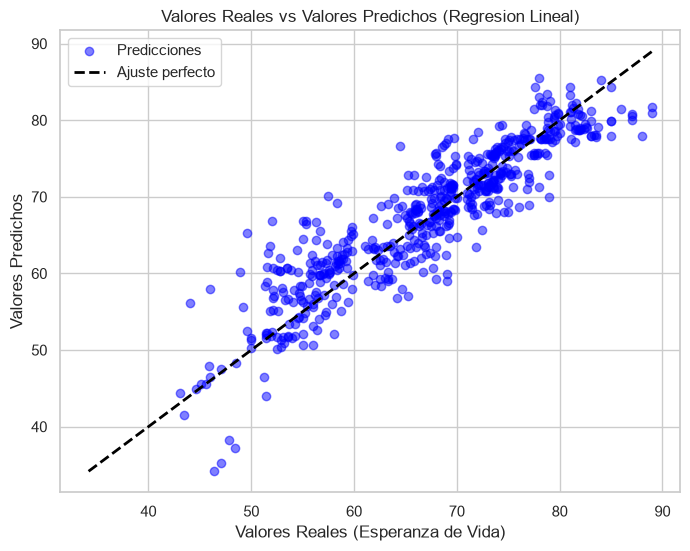

In [195]:
# Valores Reales vs Valores Predichos
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_test, color="blue", alpha=0.5, label="Predicciones")
min_val = min(y_test.min(), y_pred_test.min())
max_val = max(y_test.max(), y_pred_test.max())
plt.plot([min_val, max_val], [min_val, max_val], color="black", linestyle="--", linewidth=2, label="Ajuste perfecto")
plt.title("Valores Reales vs Valores Predichos (Regresion Lineal)")
plt.xlabel("Valores Reales (Esperanza de Vida)")
plt.ylabel("Valores Predichos")
plt.legend()
plt.show()

Los puntos se agrupan muy cerca de la linea de ajuste perfecto (diagonal negra), lo cual indica que el modelo predice con buena precision. Sin embargo, se observa mayor dispersion en los extremos: para paises con esperanza de vida muy baja (<55 anios), el modelo tiende a sobreestimar, y para los mas altos (>80 anios), tiende a subestimar ligeramente. Algo comun un modelo lineal que "promedia" hacia el centro de los datos.

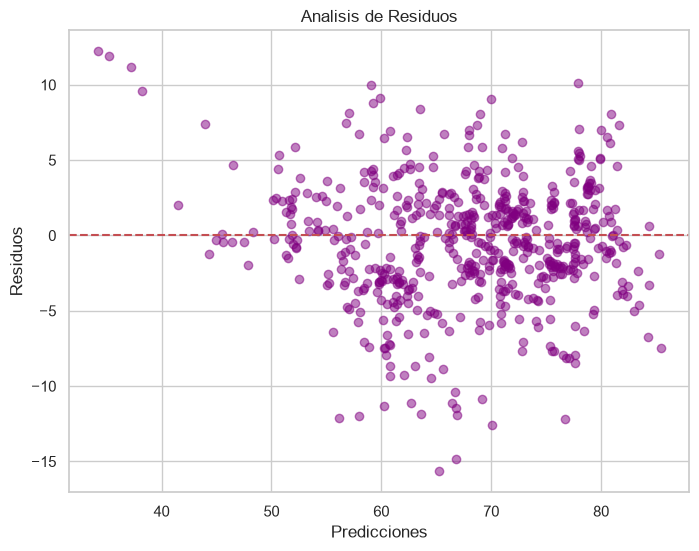

In [196]:
# Grafico de residuos (verificacion de los supuestos del modelo lineal)
residuos = y_test.values - y_pred_test

plt.figure(figsize=(8, 6))
plt.scatter(y_pred_test, residuos, alpha=0.5, color="purple")
plt.axhline(y=0, color="r", linestyle="--")
plt.xlabel("Predicciones")
plt.ylabel("Residuos")
plt.title("Analisis de Residuos")
plt.show()

Si el modelo fuera perfecto, los residuos formarian una nube aleatoria alrededor de y=0 (linea roja). En este caso se observa que la dispersion es razonablemente uniforme (homocedasticidad aceptable). Sin embargo, el modelo tiende a subestimar a los paises con prediccion baja (<55 anios), y la mayor dispersion de residuos se concentra en el rango 65-75 anios. Los demas valores se comportan bien, con errores pequenios. No se detecta un patron curvo sistematico, por lo que el supuesto de linealidad se cumple razonablemente.

### 8. Interpretacion de Coeficientes
Al estar las variables escaladas con `StandardScaler`, los coeficientes del modelo son directamente comparables entre si. Los valores positivos empujan la esperanza de vida hacia arriba, y los negativos hacia abajo.

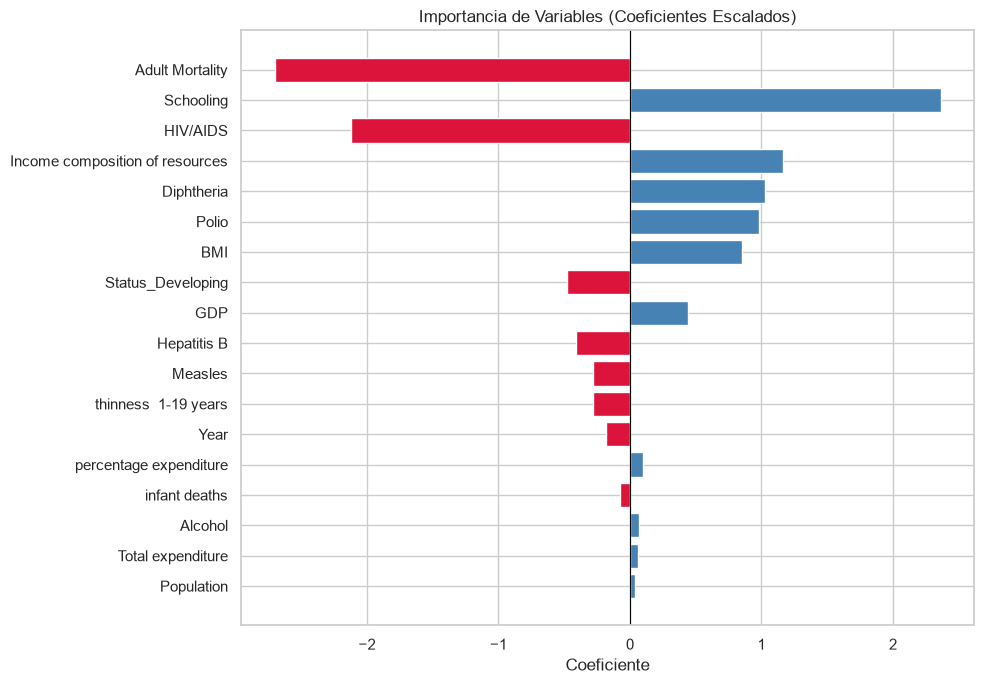

Variables mas influyentes:


,Variable,Coeficiente
1,Adult Mortality,-2.703112
16,Schooling,2.362899
11,HIV/AIDS,-2.119472
15,Income composition of resources,1.162709
10,Diphtheria,1.026991


In [197]:
# Extraer coeficientes del modelo dentro del pipeline
modelo_lr = pipeline_lr.named_steps["model"]
coef_df = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente": modelo_lr.coef_
}).sort_values("Coeficiente", key=abs, ascending=True)

plt.figure(figsize=(10, 7))
colors = ["crimson" if c < 0 else "steelblue" for c in coef_df["Coeficiente"]]
plt.barh(coef_df["Variable"], coef_df["Coeficiente"], color=colors)
plt.axvline(x=0, color="black", linewidth=0.8)
plt.title("Importancia de Variables (Coeficientes Escalados)")
plt.xlabel("Coeficiente")
plt.tight_layout()
plt.show()

print("Variables mas influyentes:")
top = coef_df.reindex(coef_df["Coeficiente"].abs().sort_values(ascending=False).index).head(5)
display(top)

**Conclusiones de los coeficientes:**
- **Adult Mortality** y **HIV/AIDS** tienen los coeficientes negativos mas fuertes: a mayor mortalidad adulta o mayor prevalencia de VIH, menor esperanza de vida.
- **Schooling** es el predictor positivo mas fuerte, seguido de **Income composition of resources**, **Diphtheria** y **Polio**.
- Estos resultados son coherentes con la intuicion.

### 9. Comparacion con Ridge Regression
En la teoria de la clase se presenta la regresion contraida (Ridge). Comparamos ambos modelos para ver si la regularizacion L2 mejora el rendimiento, especialmente con predictores correlacionados. Usamos `RidgeCV` que elige automaticamente el mejor alpha mediante validacion cruzada.

In [198]:
# Pipeline Ridge con validacion cruzada para elegir alpha
pipeline_ridge = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0])),
])

pipeline_ridge.fit(X_train, y_train)
y_pred_ridge = pipeline_ridge.predict(X_test)

alpha_elegido = pipeline_ridge.named_steps["model"].alpha_
r2_lr = metrics.r2_score(y_test, y_pred_test)
r2_ridge = metrics.r2_score(y_test, y_pred_ridge)

print(f"Regresion Lineal   -> R2 en test: {r2_lr:.4f}")
print(f"Ridge (alpha={alpha_elegido})  -> R2 en test: {r2_ridge:.4f}")
print()
diff = abs(r2_ridge - r2_lr)
if diff < 0.005:
    print(f"Ambos modelos rinden de forma practicamente identica (diferencia: {diff:.4f}). La regularizacion no aporta una mejora significativa en este caso.")
elif r2_ridge > r2_lr:
    print(f"Ridge mejora el rendimiento en {diff:.4f} puntos de R2 gracias a la regularizacion.")
else:
    print(f"La Regresion Lineal clasica supera a Ridge por {diff:.4f} puntos de R2.")


Regresion Lineal   -> R2 en test: 0.8208
Ridge (alpha=100.0)  -> R2 en test: 0.8224

Ambos modelos rinden de forma practicamente identica (diferencia: 0.0016). La regularizacion no aporta una mejora significativa en este caso.


In [199]:
# Validacion cruzada por grupos (GroupKFold) para estimacion mas robusta
from sklearn.model_selection import cross_val_score, GroupKFold

gkf = GroupKFold(n_splits=5)
scores_cv = cross_val_score(pipeline_lr, X, y, groups=paises, cv=gkf, scoring="r2")

print(f"R2 por fold: {[round(s, 4) for s in scores_cv]}")
print(f"R2 medio: {scores_cv.mean():.4f} +/- {scores_cv.std():.4f}")


R2 por fold: [np.float64(0.85), np.float64(0.8121), np.float64(0.7945), np.float64(0.5833), np.float64(0.7283)]
R2 medio: 0.7537 +/- 0.0939


### 10. Caso de Uso Practico: Prediccion en Vivo
Si ingresamos los datos de un nuevo pais ficticio a nuestro sistema. El modelo aplicara todo lo aprendido para estimar la expectativa de vida promedio de sus habitantes.

In [200]:
# Creamos un nuevo pais con valores aproximados a la media global
datos_nuevo_pais = {}
for col in X.columns:
    datos_nuevo_pais[col] = df[col].median()

# Alteramos algunos valores para simular un pais desarrollado
datos_nuevo_pais["Income composition of resources"] = 0.90
datos_nuevo_pais["Schooling"] = 15.0
datos_nuevo_pais["Adult Mortality"] = 80.0
datos_nuevo_pais["Status_Developing"] = 0.0

nuevo_pais_df = pd.DataFrame([datos_nuevo_pais])

# El pipeline se encarga de imputar y escalar automaticamente
prediccion_en_vivo = pipeline_lr.predict(nuevo_pais_df)

print("=" * 44)
print("     PREDICCION PARA NUEVO PAIS FICTICIO")
print("=" * 44)
print(f"  > Desarrollo (Ingresos): {datos_nuevo_pais['Income composition of resources']}")
print(f"  > Escolaridad (Anios): {datos_nuevo_pais['Schooling']}")
print(f"  > Mortalidad Adulta: {datos_nuevo_pais['Adult Mortality']}")
print("-" * 44)
print(f"🤖 El modelo estima una expectativa de vida de: {prediccion_en_vivo[0]:.1f} anios")
print("=" * 44)

     PREDICCION PARA NUEVO PAIS FICTICIO
  > Desarrollo (Ingresos): 0.9
  > Escolaridad (Anios): 15.0
  > Mortalidad Adulta: 80.0
--------------------------------------------
🤖 El modelo estima una expectativa de vida de: 77.7 anios


### 11. Conclusiones Finales

**Rendimiento del modelo:** La Regresion Lineal logra un R2 cercano a 0.82 en el split unico y aproximadamente 0.75 en validacion cruzada por grupos (GroupKFold, 5 folds). Esto significa que el modelo explica de forma robusta entre el 75% y el 82% de la variabilidad en la esperanza de vida.

**Limitaciones identificadas:**
- **Imputacion fuerte:** Las columnas `Population` (22% nulos), `Hepatitis B` (19%) y `GDP` (15%) requirieron una imputacion masiva con la mediana. Esto introduce datos sinteticos que pueden suavizar relaciones reales, especialmente en paises con datos faltantes sistematicos.
- **Modelo lineal:** Asumimos que las relaciones entre predictores y esperanza de vida son lineales. Los graficos de residuos muestran que esto es razonable en el rango central, pero el modelo subestima en los extremos bajos (<55 anios) y presenta mayor dispersion en el rango 55-65. Un modelo no lineal (arboles, redes neuronales, etc) podria capturar mejor esas zonas.
- **Validacion cruzada:** El R2 en GroupKFold (~0.75) es menor que en el split unico (~0.82), lo cual sugiere que el rendimiento real del modelo es algo menor al estimado con una sola particion. Algunos folds muestran valores mas bajos, indicando que el modelo generaliza peor para ciertos grupos de paises.
- **Causalidad vs. correlacion:** Los coeficientes del modelo muestran asociaciones estadisticas, no relaciones causales. Por ejemplo, la escolaridad se asocia a mayor esperanza de vida, pero el modelo no prueba que una cause la otra.